In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import h5py

import os
import sys
sys.path.append(os.path.abspath("./"))

print(os.getpid())
%cd ../../

import pylib.mix as mix
import carleman as ca
from matplotlib import colors
plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

28656
c:\Users\ivan9\Documents\work\codes\QuCF\scripts-py


In [2]:
path_save_ = "./jupyter-notebooks/Carleman/results/"
for i in range(100):
    plt.close()

colors_     = ["blue", "red", "green", "gray", "black"]
linestyles_ = ["-", "--", "--", ":"]

init. cond.:   0.20   0.20   0.20 




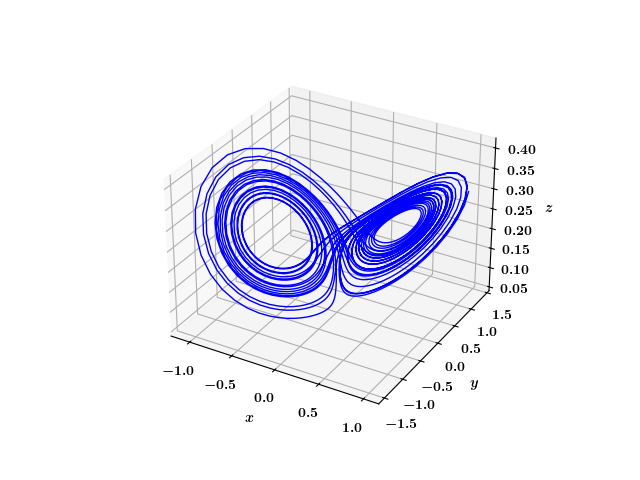

c:\Users\ivan9\Documents\work\codes\QuCF\scripts-py\jupyter-notebooks\Carleman\carleman.py:103: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  def solve_carleman_orig(x_init, N_nl_emb, N_nl_sys, t, F_terms):


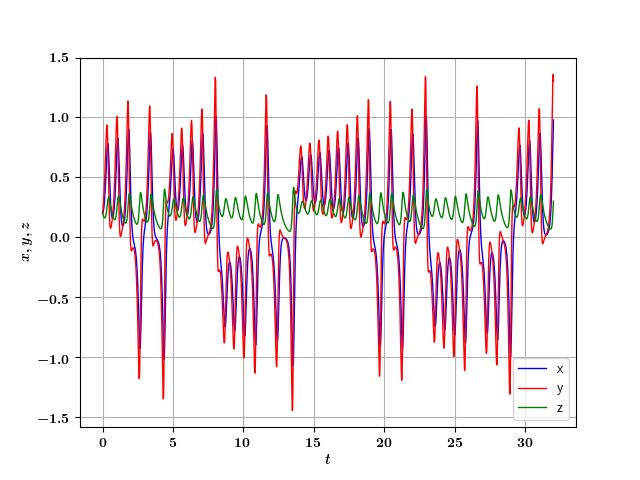

In [24]:
# ---------------------------------------------------------------
# --- Prepare the system ---
# ---------------------------------------------------------------
mix.reload_module(ca)
mix.reload_module(mix)
def choose_case(N_nl, sel_case):
    Nx = 3  # the number of degrees of freedom

    sys_coefs, return_sys, shift_coefs = None, None, None

    F_terms = [None] * (N_nl + 1)
    for ii_nl in range(N_nl + 1):
        F_terms[ii_nl] = np.zeros((Nx,int(Nx**ii_nl)))

    # --- Lorentz attractor ---
    # rr < 1:            one fixed point (0,0,0):    a single stable point
    # 1 < rr < 24.74:    three fixed points: two stable symmetric points and one unstable
    # rr > 24.74: chaos: three fixed points: three unstable points
    # two symmetric points: (+- np.sqrt(bb*(rr-1.)), +- np.sqrt(bb*(rr-1.)), rr - 1)
    # ---
    # rescaling factors: just for reference:
    # scale_x = np.sqrt(cx*bb*(rr-1.))
    # scale_y = np.sqrt(cy*bb*(rr-1.))
    # scale_z = cz*(rr - 1.)

    # ----------------------------------------------------
    # --- Lorentz attractor (strange attractor) ---
    if sel_case == 0:
        # tmax, nt = 40, 12
        # tmax, nt = 4, 9
        # tmax, nt = 8, 10
        tmax, nt = 16, 11

        # ss, rr, bb = 10., 28., 8./3.
        # ss, rr, bb = 4, 28., 8./3.
        # ss, rr, bb = 10., 24.74, 8./3.

        # F = [
        #     lambda x: ss * (x[1] - x[0] ),
        #     lambda x: x[0]  * (rr - x[2]) - x[1],
        #     lambda x: x[0] *x[1]  - bb*x[2] 
        # ]

        # ss, rr, bb = 10., 28., 8./3.
        # cx, cy, cz = 8., 16., 2.

        # ss, rr, bb = 10., 0.5, 8./3.
        # cx, cy, cz = 8., 16., 2.

        # ss, rr, bb = 10., 0.5, 8./3.  # -> works
        # cx, cy, cz = 1., 1., 1.  

        ss, rr, bb = 10., 2.0, 8./3. # -> # ubstable
        cx, cy, cz = 1., 1., 1.
        x_init = np.array([0.8, 0.0, 0.0])

        a0, a1 = -ss, ss * np.sqrt(cy/cx)
        b0, b1 = np.sqrt(cx/cy) * rr, -1.
        b02 = np.sqrt(cx/cy) * cz * (-rr + 1)
        c01, c2 = np.sqrt(cx*cy)/cz*bb, -bb 
        F = [
            lambda x: a0 * x[0] + a1 * x[1],
            lambda x: b0 * x[0] + b1 * x[1] + b02 * x[0] * x[2],
            lambda x: c2 * x[2] + c01 * x[0] * x[1]
        ]

        # F = [
        #     lambda x: ss * (np.sqrt(cy/cx) * x[1] - x[0]),
        #     lambda x: np.sqrt(cx/cy) * x[0]  * (rr*(1. - cz*x[2]) + cz*x[2]) - x[1],
        #     lambda x: np.sqrt(cx*cy)/cz*bb*x[0]*x[1]  - bb*x[2] 
        # ]

        # --- Construct system matrices ---
 
        # *** matrix F1 ***
        F_terms[1][0,0], F_terms[1][0,1] = a0, a1
        F_terms[1][1,0], F_terms[1][1,1] = b0, b1
        F_terms[1][2,2] = c2

        # *** matrix F2 ***
        F_terms[2][1,2] = b02
        F_terms[2][2,1] = c01

    # ----------------------------------------------------
    # --- Lorentz attractor (strange attractor, modified) ---
    if sel_case == 1:
        tmax, nt = 4, 9

        ss, rr, bb = 10., 0.5, 8./3.  # -> works
        cx, cy, cz = 1., 1., 1. 
        x_init = np.array([0.8, 0.0, 0.0])

        # ss, rr, bb = 10., 28.0, 8./3.  # -> 
        # cx, cy, cz = 1., 1., 1.

        a0, a1 = -ss, ss * np.sqrt(cy/cx)
        b0, b1 = np.sqrt(cx/cy) * rr, -1.
        b02 = np.sqrt(cx/cy) * cz * (-rr + 1)
        c01, c2 = np.sqrt(cx*cy)/cz*bb, -bb 
        xc0 = 0.6
        F = [
            lambda x: a0 * (x[0] - xc0) + a1 * x[1],
            lambda x: b0 * (x[0] - xc0)  + b1 * x[1] + b02 * (x[0] - xc0)  * x[2],
            lambda x: c2 * x[2] + c01 * (x[0] - xc0) * x[1]
        ]

        # *** matrix F0 ***
        F_terms[0][0,0] = - a0 * xc0
        F_terms[0][1,0] = - b0 * xc0

        # *** matrix F1 ***
        F_terms[1][0,0], F_terms[1][0,1] = a0, a1
        F_terms[1][1,0], F_terms[1][1,1], F_terms[1][1,2]  = b0, b1, - b02 * xc0
        F_terms[1][2,1], F_terms[1][2,2] = -c01 * xc0, c2

        # *** matrix F2 ***
        F_terms[2][1,2] = b02
        F_terms[2][2,1] = c01

        # ------------------------------------------------
        # --- ref ---
        # F = [
        #     lambda x: a0 * x[0] + a1 * x[1],
        #     lambda x: b0 * x[0] + b1 * x[1] + b02 * x[0] * x[2],
        #     lambda x: c2 * x[2] + c01 * x[0] * x[1]
        # ]
        # # *** matrix F1 ***
        # F_terms[1][0,0], F_terms[1][0,1] = a0, a1
        # F_terms[1][1,0], F_terms[1][1,1] = b0, b1
        # F_terms[1][2,2] = c2

        # # *** matrix F2 ***
        # F_terms[2][1,2] = b02
        # F_terms[2][2,1] = c01

    # ----------------------------------------------------
    # --- Lorentz attractor: one stable point ---
    if sel_case == 2:
        tmax, nt = 4, 9

        ss, rr, bb = 10., 0.5, 8./3.  # -> works
        cx, cy, cz = 1., 1., 1. 
        xc0 = 0.6
        x_init = np.array([0.8, 0.0, 0.0])

        a0, a1 = -ss, ss * np.sqrt(cy/cx)
        b0, b1 = np.sqrt(cx/cy) * rr, -1.
        b02 = np.sqrt(cx/cy) * cz * (-rr + 1)
        c01, c2 = np.sqrt(cx*cy)/cz*bb, -bb 
        F = [
            lambda x: a0 * (x[0] - xc0) + a1 * x[1],
            lambda x: b0 * (x[0] - xc0)  + b1 * x[1] + b02 * (x[0] - xc0)  * x[2],
            lambda x: c2 * x[2] + c01 * (x[0] - xc0) * x[1]
        ]

        # *** matrix F0 ***
        F_terms[0][0,0] = - a0 * xc0
        F_terms[0][1,0] = - b0 * xc0

        # *** matrix F1 ***
        F_terms[1][0,0], F_terms[1][0,1] = a0, a1
        F_terms[1][1,0], F_terms[1][1,1], F_terms[1][1,2]  = b0, b1, - b02 * xc0
        F_terms[1][2,1], F_terms[1][2,2] = -c01 * xc0, c2

        # *** matrix F2 ***
        F_terms[2][1,2] = b02
        F_terms[2][2,1] = c01

    # ----------------------------------------------------
    # --- Lorentz attractor: two stable points, one unstable ---
    if sel_case == 3:
        tmax, nt = 8, 10

        # ss, rr, bb = 10., 4.2, 8./3.  # -> works
        # cx, cy, cz = 1., 1., 1. 
        # xc0 = 0.0
        # x_init = np.array([-1.2, 0.0, 0.0])

        ss, rr, bb = 10., 4.2, 8./3.  # -> works
        cx, cy, cz = 2., 2., 2. 
        xc0 = -1.2
        x_init = np.array([0.0, 0.0, 0.0])

        a0, a1 = -ss, ss * np.sqrt(cy/cx)
        b0, b1 = np.sqrt(cx/cy) * rr, -1.
        b02 = np.sqrt(cx/cy) * cz * (-rr + 1)
        c01, c2 = np.sqrt(cx*cy)/cz*bb, -bb 
        F = [
            lambda x: a0 * (x[0] - xc0) + a1 * x[1],
            lambda x: b0 * (x[0] - xc0)  + b1 * x[1] + b02 * (x[0] - xc0) * x[2],
            lambda x: c2 * x[2] + c01 * (x[0] - xc0) * x[1]
        ]

        # *** matrix F0 ***
        F_terms[0][0,0] = - a0 * xc0
        F_terms[0][1,0] = - b0 * xc0

        # *** matrix F1 ***
        F_terms[1][0,0], F_terms[1][0,1] = a0, a1
        F_terms[1][1,0], F_terms[1][1,1], F_terms[1][1,2]  = b0, b1, - b02 * xc0
        F_terms[1][2,1], F_terms[1][2,2] = -c01 * xc0, c2

        # *** matrix F2 ***
        F_terms[2][1,2] = b02
        F_terms[2][2,1] = c01

    # ----------------------------------------------------------
    # --- Lorentz attractor: shifted center ---
    if sel_case == 4:
        tmax, nt = 32, 11

        ss, rr, bb = 10., 0.4, 8./3.  
        cx, cy, cz = 1., 1., 1. 

        # xc0, yc0, zc0 = 0.8, 0.6, 0.4
        # xc0, yc0, zc0 = 0.8, 0.0, 0.6

        xc0, yc0, zc0 = 0.0, 0.8, 0.0
        x_init = np.array([0.1, 0.2, 0.9])

        # xc0, yc0, zc0 = 0.0, 0.0, 0.8
        # x_init = np.array([0.1, 0.9, 0.2])

        a0, a1 = -ss, ss * np.sqrt(cy/cx)
        b0, b1 = np.sqrt(cx/cy) * rr, -1.
        b02 = np.sqrt(cx/cy) * cz * (-rr + 1)
        c01, c2 = np.sqrt(cx*cy)/cz*bb, -bb 
        F = [
            lambda x: a0 * (x[0] - xc0) + a1 * (x[1] - yc0),
            lambda x: b0 * (x[0] - xc0) + b1 * (x[1] - yc0) + b02 * (x[0] - xc0) * (x[2] - zc0),
            lambda x: c2 * (x[2] - zc0) + c01 * (x[0] - xc0) * (x[1] - yc0)
        ]

        # *** matrix F0 ***
        F_terms[0][0,0] = - a0 * xc0 - a1 * yc0
        F_terms[0][1,0] = - b0 * xc0 - b1 * yc0 + b02 * xc0 * zc0
        F_terms[0][2,0] = - c2 * zc0 + c01 * xc0 * yc0 

        # *** matrix F1 ***
        F_terms[1][0,0], F_terms[1][0,1] = a0, a1
        F_terms[1][1,0], F_terms[1][1,1], F_terms[1][1,2]  = b0 - b02 * zc0, b1, - b02 * xc0
        F_terms[1][2,0], F_terms[1][2,1], F_terms[1][2,2] = -c01 * yc0, -c01 * xc0, c2

        # *** matrix F2 ***
        F_terms[2][1,2] = b02
        F_terms[2][2,1] = c01

    # ----------------------------------------------------------
    # --- Lorentz attractor: shifted center: rechecked ---
    if sel_case == 5:
        tmax, nt = 32, 11

        # # --- a single stable point (problematic)  ---
        # ss, rr, bb = 10., 0.4, 8./3.  
        # cx, cz = 1., 1.
        # xc0, yc0, zc0 = 0.0, 0.8, 0.0
        # x_init = np.array([0.1, 0.2, 0.9])

        # # --- a single stable point (working)  ---
        # ss, rr, bb = 10., 0.4, 8./3.  
        # cx, cz = 1., 1.
        # xc0, yc0, zc0 = 0.8, 0.0, 0.4
        # x_init = np.array([0.1, 0.2, 0.9])

        # # --- OPT1: stable point in the case with three fixed points (working) ---
        # ss, rr, bb = 10., 2.4, 8./3.  
        # cx, cz = 2., 2. 
        # xc0, yc0, zc0 = -0.7, -0.7, -0.5
        # x_init = np.array([0.2, 0.2, 0.2])

        # --- OPT2: stable point in the case with three fixed points (worse) ---
        ss, rr, bb = 10., 10.4, 8./3.  
        cx, cz = 4., 4. 
        xc0, yc0, zc0 = -0.5, -0.5, -0.25
        x_init = np.array([0.2, 0.2, 0.2])

        # # --- OPT3: stable point in the case with three fixed points (worse) ---
        # ss, rr, bb = 10., 10.4, 8./3.  
        # cx, cz = 4., 4. 
        # xc0, yc0, zc0 = 0.5, 0.5, -0.25
        # x_init = np.array([0.2, 0.2, 0.20])

        # --- construct the system ---
        eta_x_2 = cx*bb*(rr - 1)
        eta_z = cz*(rr - 1)
        c02 = eta_x_2 / eta_z

        fx_x, fx_y, fx_0 = -ss, ss, ss * (xc0 - yc0)
        fy_xz, fy_x, fy_y, fy_z = - eta_z, rr + eta_z*zc0, -1, eta_z*xc0
        fy_0                    = yc0 - rr*xc0 - eta_z*xc0*zc0
        fz_xy, fz_x, fz_y, fz_z = c02, -c02*yc0, -c02*xc0, -bb 
        fz_0                    = bb*zc0 + c02*xc0*yc0
        F = [
            lambda x: fx_x * x[0] + fx_y * x[1] + fx_0,
            lambda x: fy_xz * x[0] * x[2] + fy_x * x[0] + fy_y * x[1] + fy_z * x[2] + fy_0,
            lambda x: fz_xy * x[0] * x[1] + fz_x * x[0] + fz_y * x[1] + fz_z * x[2] + fz_0
        ]

        # *** matrix F0 ***
        F_terms[0][0,0] = fx_0
        F_terms[0][1,0] = fy_0
        F_terms[0][2,0] = fz_0

        # *** matrix F1 ***
        F_terms[1][0,0], F_terms[1][0,1] = fx_x, fx_y
        F_terms[1][1,0], F_terms[1][1,1], F_terms[1][1,2] = fy_x, fy_y, fy_z
        F_terms[1][2,0], F_terms[1][2,1], F_terms[1][2,2] = fz_x, fz_y, fz_z

        # *** matrix F2 ***
        F_terms[2][1,2] = fy_xz
        F_terms[2][2,1] = fz_xy

    # ----------------------------------------------------------
    # --- Lorentz attractor: new normalization ---
    if sel_case == 10:
        tmax, nt = 32, 11


        # ss, rr, bb = 10., 10.4, 8./3.  
        # cx, cz = 2., 4. 
        # # xi_x, xi_y, xi_z = 0.5, 0.5, 0.25
        # xi_x, xi_y, xi_z = 0.0, 0.0, 0.0
        # x_init = np.array([0.2, 0.2, 0.2])

        ss, rr, bb = 10., 28, 8./3.  
        cx, cz = 2., 4. 
        xi_x, xi_y, xi_z = 0.0, 0.0, 0.0
        x_init = np.array([0.2, 0.2, 0.2])

        sys_coefs = {}
        sys_coefs["ss"]   = ss
        sys_coefs["rr"]   = rr
        sys_coefs["bb"]   = bb
        sys_coefs["xi_x"] = xi_x
        sys_coefs["xi_y"] = xi_y
        sys_coefs["xi_z"] = xi_z
        sys_coefs["cx"]   = cx
        sys_coefs["cz"]   = cz

        # -------------------------------------------------------------
        def return_sys(ss_coefs):
            ss   = ss_coefs["ss"]    
            rr   = ss_coefs["rr"]    
            bb   = ss_coefs["bb"]    
            xi_x = ss_coefs["xi_x"]  
            xi_y = ss_coefs["xi_y"]  
            xi_z = ss_coefs["xi_z"]  
            cx   = ss_coefs["cx"]    
            cz   = ss_coefs["cz"] 

            eta_x_2 = cx**2 * bb * (rr - 1)
            eta_z = cz*(rr - 1)
            eta = eta_x_2 / eta_z 

            F_terms = [None] * (N_nl + 1)
            for ii_nl in range(N_nl + 1):
                F_terms[ii_nl] = np.zeros((Nx,int(Nx**ii_nl)))

            # *** matrix F0 ***
            F_terms[0][0,0] = ss * (xi_y - xi_x)
            F_terms[0][1,0] = rr*xi_x - xi_y - eta_z*xi_x*xi_z
            F_terms[0][2,0] = eta*xi_x*xi_y - bb*xi_z

            # *** matrix F1 ***
            F_terms[1][0,0], F_terms[1][0,1] = -ss, ss
            F_terms[1][1,0], F_terms[1][1,1], F_terms[1][1,2] = rr - eta_z*xi_z,       -1, -eta_z*xi_x
            F_terms[1][2,0], F_terms[1][2,1], F_terms[1][2,2] =        eta*xi_y, eta*xi_x,         -bb 

            # *** matrix F2 ***
            F_terms[2][1,2] = - eta_z
            F_terms[2][2,1] = eta

            return F_terms
        
        # -------------------------------------------------------------
        def shift_coefs(ss, zeta):
            ss_new = dict(ss)
            ss_new["xi_x"] = ss_new["xi_x"] + zeta[0]
            ss_new["xi_y"] = ss_new["xi_y"] + zeta[1]
            if "xi_z" in ss_new:
                ss_new["xi_z"] = ss_new["xi_z"] + zeta[2]
            return ss_new

        # --- construct the system ---
        F_terms = return_sys(sys_coefs)
        F = [
            lambda x: F_terms[0][0,0] + F_terms[1][0,0] * x[0] + F_terms[1][0,1] * x[1],
            lambda x: F_terms[0][1,0] + F_terms[1][1,0] * x[0] + F_terms[1][1,1] * x[1] + F_terms[1][1,2] * x[2] + F_terms[2][1,2] * x[0] * x[2],
            lambda x: F_terms[0][2,0] + F_terms[1][2,0] * x[0] + F_terms[1][2,1] * x[1] + F_terms[1][2,2] * x[2] + F_terms[2][2,1] * x[0] * x[1]
        ]


    # ----------------------------------------------------------
    # --- Lorentz attractor: without rescaling ---
    if sel_case == 100:
        tmax, nt = 32, 11

        ss, rr, bb = 10., 28, 8./3.  
        xi_x, xi_y, xi_z = 0.0, 0.0, 0.0
        x_init = np.array([0.2, 0.2, 0.2])

        sys_coefs = {}
        sys_coefs["ss"]   = ss
        sys_coefs["rr"]   = rr
        sys_coefs["bb"]   = bb
        sys_coefs["xi_x"] = xi_x
        sys_coefs["xi_y"] = xi_y
        sys_coefs["xi_z"] = xi_z

        # -------------------------------------------------------------
        def return_sys(ss_coefs):
            ss   = ss_coefs["ss"]    
            rr   = ss_coefs["rr"]    
            bb   = ss_coefs["bb"]    
            xi_x = ss_coefs["xi_x"]  
            xi_y = ss_coefs["xi_y"]  
            xi_z = ss_coefs["xi_z"]  

            F_terms = [None] * (N_nl + 1)
            for ii_nl in range(N_nl + 1):
                F_terms[ii_nl] = np.zeros((Nx,int(Nx**ii_nl)))

            # *** matrix F0 ***
            F_terms[0][0,0] = ss * (xi_y - xi_x)
            F_terms[0][1,0] = rr*xi_x - xi_y - xi_x*xi_z
            F_terms[0][2,0] = xi_x*xi_y - bb*xi_z

            # *** matrix F1 ***
            F_terms[1][0,0], F_terms[1][0,1] = -ss, ss
            F_terms[1][1,0], F_terms[1][1,1], F_terms[1][1,2] = rr - xi_z,  -1., -xi_x
            F_terms[1][2,0], F_terms[1][2,1], F_terms[1][2,2] =      xi_y, xi_x,   -bb 

            # *** matrix F2 ***
            F_terms[2][1,2] = - 1.
            F_terms[2][2,1] = 1.

            return F_terms
        
        # -------------------------------------------------------------
        def shift_coefs(ss, zeta):
            ss_new = dict(ss)
            ss_new["xi_x"] = ss_new["xi_x"] + zeta[0]
            ss_new["xi_y"] = ss_new["xi_y"] + zeta[1]
            if "xi_z" in ss_new:
                ss_new["xi_z"] = ss_new["xi_z"] + zeta[2]
            return ss_new

        # --- construct the system ---
        F_terms = return_sys(sys_coefs)
        F = [
            lambda x: F_terms[0][0,0] + F_terms[1][0,0] * x[0] + F_terms[1][0,1] * x[1],
            lambda x: F_terms[0][1,0] + F_terms[1][1,0] * x[0] + F_terms[1][1,1] * x[1] + F_terms[1][1,2] * x[2] + F_terms[2][1,2] * x[0] * x[2],
            lambda x: F_terms[0][2,0] + F_terms[1][2,0] * x[0] + F_terms[1][2,1] * x[1] + F_terms[1][2,2] * x[2] + F_terms[2][2,1] * x[0] * x[1]
        ]

    # ----------------------------------------------------
    return F, tmax, nt, Nx, x_init, F_terms, sys_coefs, return_sys, shift_coefs
# ------------------------------------------------------------------------------
sel_case_ = 10

N_nl_orig_ = 2
F_, tmax_, nt_, Nx_, x_init_ref_, F_terms_, sys_coefs_, return_sys_, shift_coefs_ = choose_case(N_nl_orig_, sel_case = sel_case_)
Nt_ = 1 << nt_
t_ = np.linspace(0, tmax_, Nt_)
dt_ = np.diff(t_)[0]

print("init. cond.: ", end = "")
mix.print_array(x_init_ref_, ff = [6, 2, "f"])

# --- Standard method (for reference) ---
sol_ref_, t_ref_ = ca.analyse_classical(x_init_ref_, t_, F_)

In [ ]:
# --------------------------------------------------------------------
# --- Carleman linearization ---
# --------------------------------------------------------------------
mix.reload_module(ca)
N_nl = 6   # should be >= N_nl_orig_

# sol_emb_, t_emb_, case_emb_ = ca.solve_carleman_orig(x_init_ref_, N_nl, N_nl_orig_, t_, return_sys_(sys_coefs_))
# sol_emb_, t_emb_, case_emb_ = ca.solve_carleman_orig(x_init_ref_, N_nl, N_nl_orig_, t_, F_terms_)

sol_emb_, t_emb_, case_emb_ = ca.solve_carleman_global(
    x_init_ref_, N_nl, N_nl_orig_, t_,     
    sys_coefs_, return_sys_, shift_coefs_,
    zeta_th = 0.1
)

The total number of variables in the embedding: 1092
--- Shift to another chart, t = 0.016 ---
radius: 0.4
zeta_gl:   0.20   0.22   0.19 
xs:      2.013e-01      2.179e-01      1.935e-01 

--- Shift to another chart, t = 0.089 ---
radius: 0.1
zeta_gl:   0.24   0.33   0.17 
xs:      4.008e-02      1.162e-01     -2.385e-02 

--- Shift to another chart, t = 0.132 ---
radius: 0.1
zeta_gl:   0.29   0.43   0.16 
xs:      4.925e-02      9.734e-02     -7.294e-03 

--- Shift to another chart, t = 0.174 ---
radius: 0.1
zeta_gl:   0.36   0.56   0.16 
xs:      7.077e-02      1.240e-01     -1.859e-04 

--- Shift to another chart, t = 0.201 ---
radius: 0.1
zeta_gl:   0.42   0.65   0.17 
xs:      5.645e-02      9.050e-02      4.952e-03 

--- Shift to another chart, t = 0.227 ---
radius: 0.1
zeta_gl:   0.48   0.74   0.18 
xs:      6.512e-02      9.499e-02      1.003e-02 

--- Shift to another chart, t = 0.254 ---
radius: 0.1
zeta_gl:   0.55   0.83   0.19 
xs:      7.179e-02      9.037e-02      1.596e-

write data to a file: ./jupyter-notebooks/Carleman/results//REF_LA_x.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_LA_GL_x.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_LA_GL_err_x.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_LA_GL_err_y.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_LA_GL_err_z.dat


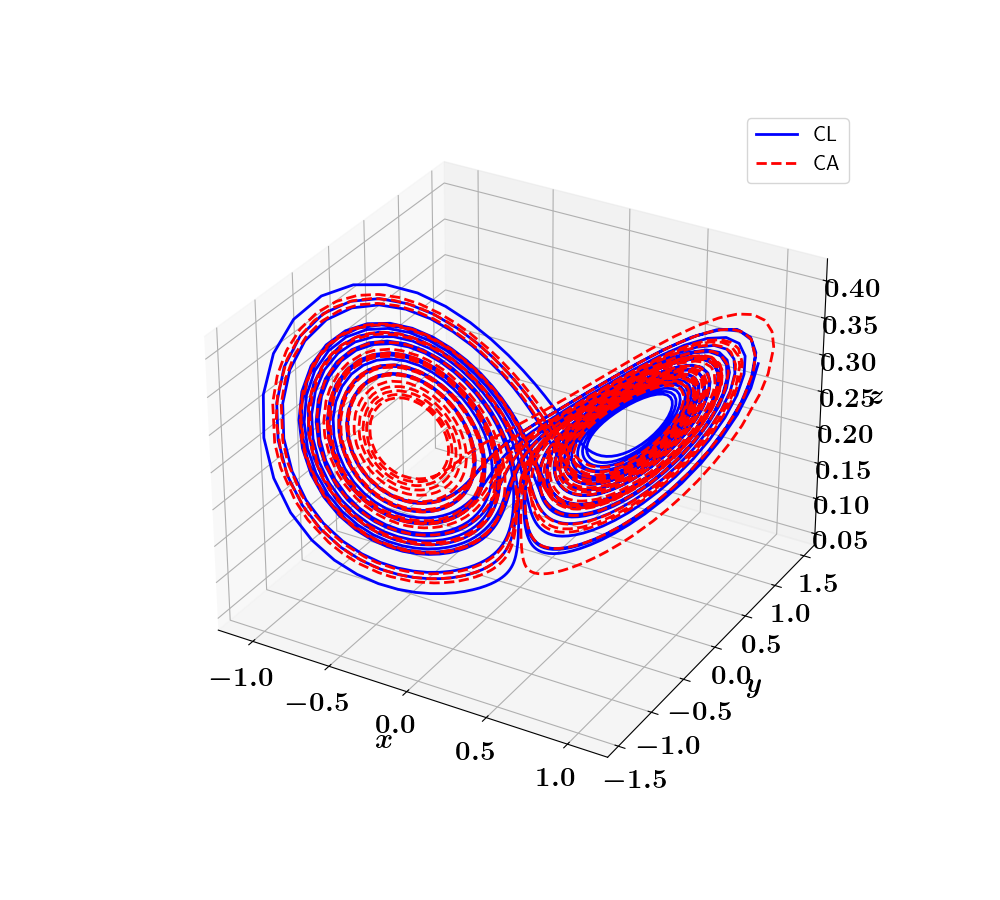

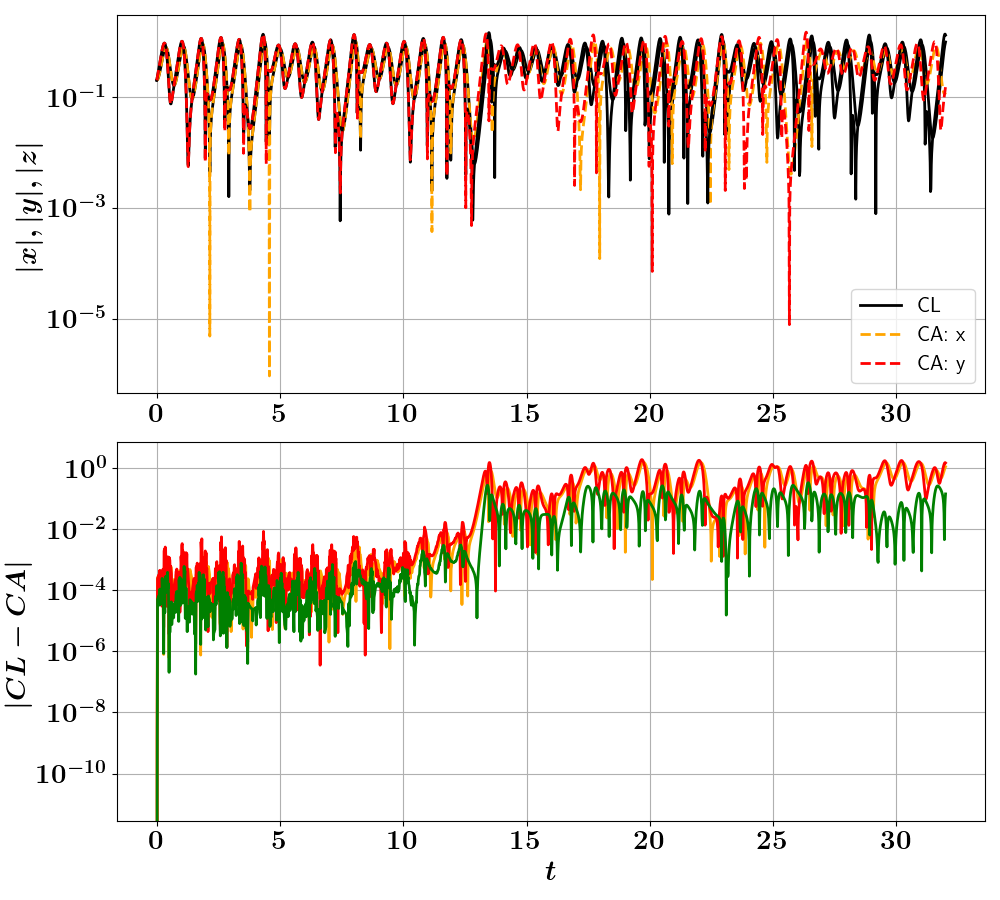

In [29]:
# --------------------------------------------------------------------
# --- Compare trajectories ---
# --------------------------------------------------------------------
mix.reload_module(ca)
ca.compare_trajectory_cl_and_carleman(
    t_ref_, sol_ref_, t_emb_, sol_emb_,
    flag_save=True, path_save=path_save_, 
    case_title = "LA", case_emb = case_emb_
)